In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..'))) 

import matplotlib.pyplot as plt
import seaborn as sns
from src import *
import numpy as np


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{mathptmx}",  # Times Roman
    "hatch.linewidth": 3.0,
})
sns.set_context("paper",font_scale=1.5)
sns.set_palette("pastel")

# 1. Simulate population

In [38]:
### 1. initiate some params
# bounds
a0_pop_min=10
a0_pop_max=20
log_mbh_min = 8
log_mbh_max = 9

# time,rate,pop size
t=1
tR=1
popN=10000
rates = np.logspace(-1,1,50)

### 2. simulate input data as uniform
# high z pop
np.random.seed(0)
a0_pop = np.random.uniform(a0_pop_min,a0_pop_max,popN)
log_mbh_sec_pop = np.random.uniform(log_mbh_min,log_mbh_max,popN)
mbh_pop= 10**log_mbh_sec_pop
q_pop = np.random.uniform(1,100,popN)

# low z pop
af_pop = af_from_a0(a0_pop,10**log_mbh_sec_pop,t=t,R=tR)

### 3. similate predicted p(af)
# define a grid of a for calculating pdfs
ap = np.linspace(0,a0_pop.max()+3,200,endpoint=True)
# estimate observed a0, assuming perfect observation
p_a0_obs = scp_kde(a0_pop,ap,return_func=True)
p_a0_obs_val = p_a0_obs(ap)
#predict p(af) at different rates
p_af_preds = paf_analytic_allrates(p_a0_obs,a0_pop,mbh_pop,t,af_grid=ap,
                        Naf=200,Na0=10000,uniform=True)

/home/insepien/dftime/src/pa.py:19: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/src/pa.py:19: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/src/pa.py:19: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/src/pa.py:19: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/src/pa.py:19: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/src/pa.py:19: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/src/pa.py:19: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/src/pa.py:19: Runti

''

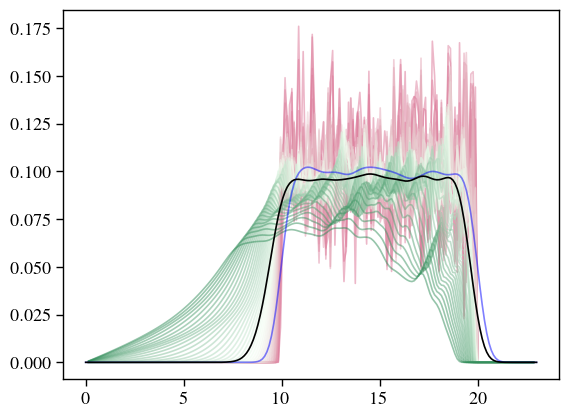

In [42]:
fig,ax = plt.subplots()


norm = mcolors.LogNorm(vmin=rates.min(), vmax=rates.max())
# custom colormap
start_color = 'palevioletred'
mid_color = 'honeydew'
end_color = 'seagreen'
cmap = LinearSegmentedColormap.from_list(
    name='custom_diverging',
    colors=[start_color, mid_color, end_color],
)
predsegs = LineCollection([np.column_stack([ap,p]) for p in list(p_af_preds.values())],colors= cmap(norm(rates)),alpha=0.5)
# plt.hist(a0_pop,alpha=0.5,density=True,label='a0')
# plt.hist(af_pop,alpha=0.5,density=True,label='af')
# plt.legend()
ax.add_collection(predsegs)
ax.autoscale_view()

ax.plot(ap,p_a0_obs_val,c='b',alpha=0.5)
ax.plot(ap,scp_kde(af_pop,ap),c='k')
;